In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 
import torch

/Users/danialmendigali/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
a = np.array([[-1, 2], [3, -2], [5, 7]])
a

array([[-1,  2],
       [ 3, -2],
       [ 5,  7]])

In [4]:
u, d, vt = np.linalg.svd(a)

In [5]:
u

array([[ 0.12708324,  0.47409506,  0.87125411],
       [ 0.00164602, -0.87847553,  0.47778451],
       [ 0.99189069, -0.0592843 , -0.11241989]])

In [6]:
vt

array([[ 0.55798885,  0.82984845],
       [-0.82984845,  0.55798885]])

In [7]:
d

array([8.66918448, 4.10429538])

In [8]:
np.diag(d)

array([[8.66918448, 0.        ],
       [0.        , 4.10429538]])

In [10]:
D = np.concatenate((np.diag(d), [[0, 0]]), axis=0)
D

array([[8.66918448, 0.        ],
       [0.        , 4.10429538],
       [0.        , 0.        ]])

In [12]:
np.dot(u, np.dot(D, vt))

array([[-1.,  2.],
       [ 3., -2.],
       [ 5.,  7.]])

In [13]:
from PIL import Image 

In [15]:
! wget https://raw.githubusercontent.com/jonkrohn/DLTFpT/master/notebooks/oboe-with-book.jpg

--2026-03-27 13:19:11--  https://raw.githubusercontent.com/jonkrohn/DLTFpT/master/notebooks/oboe-with-book.jpg
Распознаётся raw.githubusercontent.com (raw.githubusercontent.com)… 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Подключение к raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 419564 (410K) [image/jpeg]
Сохранение в: «oboe-with-book.jpg»

oboe-with-book.jpg  100%[===================>] 409,73K  1,23MB/s    за 0,3s    

2026-03-27 13:19:12 (1,23 MB/s) - «oboe-with-book.jpg» сохранён [419564/419564]



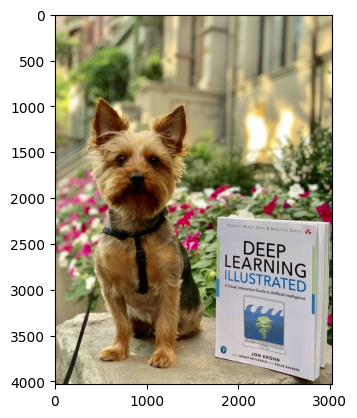

In [16]:
img = Image.open('oboe-with-book.jpg')
_ = plt.imshow(img)

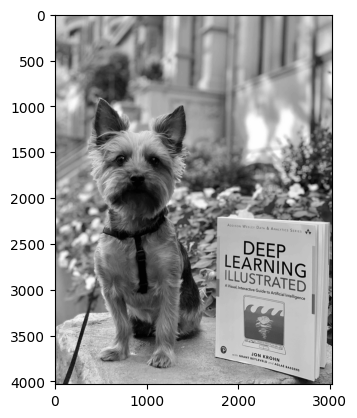

In [17]:
imggray = img.convert('LA')
_ = plt.imshow(imggray)

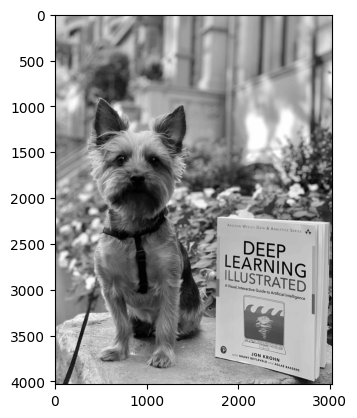

In [18]:
imgmat = np.array(list(imggray.getdata(band=0)), float)
imgmat.shape = (imggray.size[1], imggray.size[0])
imgmat = np.matrix(imgmat)
_ = plt.imshow(imgmat, cmap='gray')


In [21]:
U, sigma, V = np.linalg.svd(imgmat)

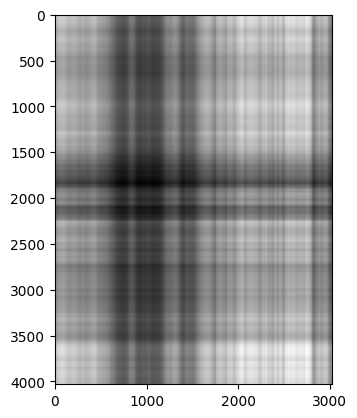

In [24]:
reconstimg = np.matrix(U[:, :1]) * np.diag(sigma[:1]) * np.matrix(V[:1, :])
_ = plt.imshow(reconstimg, cmap='gray')

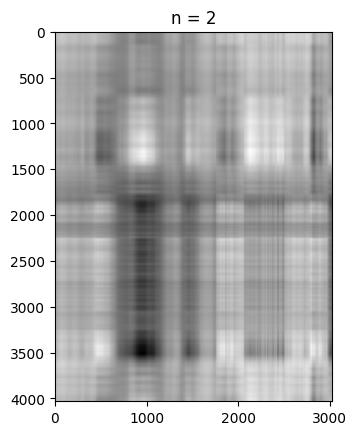

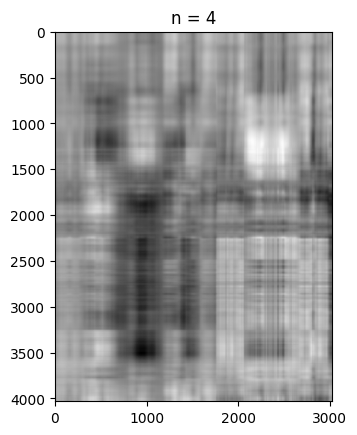

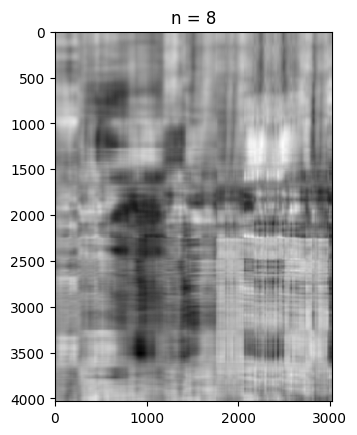

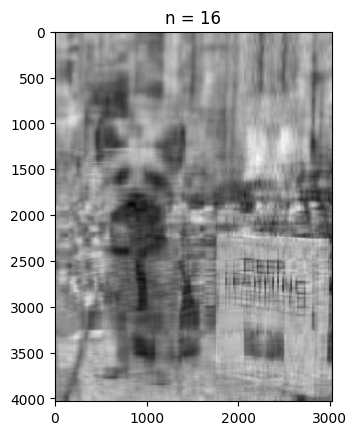

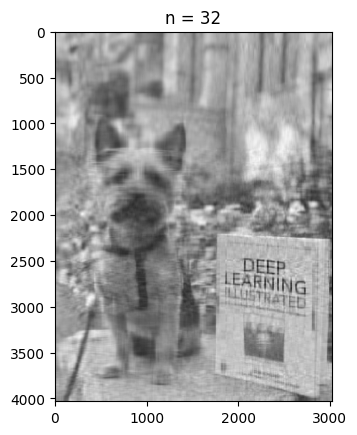

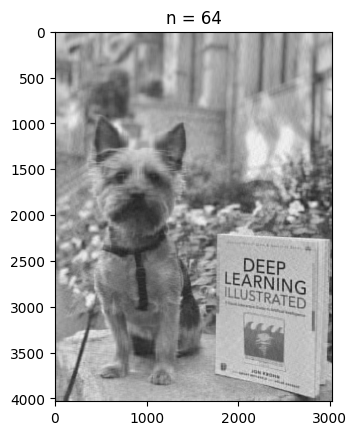

In [25]:
for i in [2, 4, 8, 16, 32, 64]:
    reconstimg = np.matrix(U[:, :i] * np.diag(sigma[:i]) * np.matrix(V[:i, :]))
    plt.imshow(reconstimg, cmap='gray')
    title = "n = %s" % i
    plt.title(title)
    plt.show()